# Sea Ice Concentration Calculation
author: Dahlia Dry

w/assistance from GitHub Copilot

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # or specify absolute path
import xarray as xr
import numpy as np
import pandas as pd
import os

# custom modules
from scripts.plotting import *
from scripts.rtm import *

## 1. Data Preprocessing

Before the tie points can be calculated, it is necessary to preprocess the input data files. In the original input data files, each file represents one orbit. The sattelite is an across-track scanner with 13 different scan angles. We can see this by plotting  as shown:

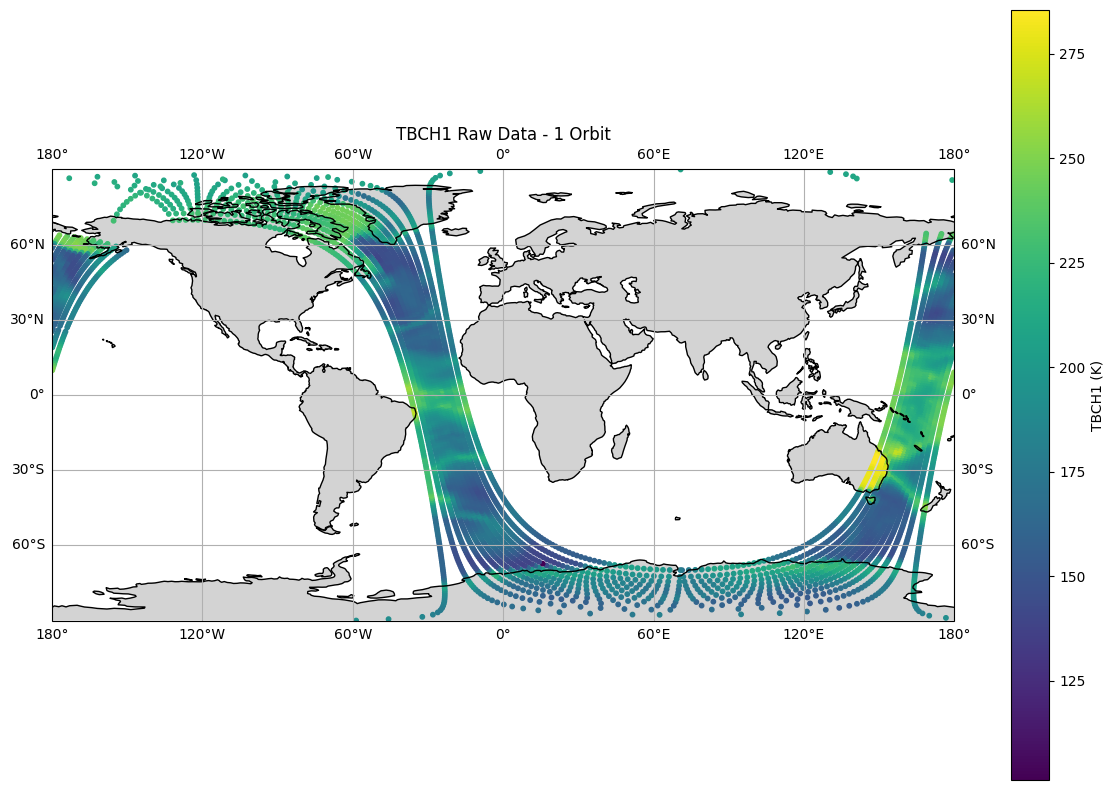

In [2]:
raw_ds = xr.open_dataset("../SCAMS_tbfixed/Nimbus6-SCAMS_1976m0301t121640_o03529_DS17_era5.nc")
plot_geo(raw_ds,raw_ds.TBCH1,title="TBCH1 Raw Data - 1 Orbit",cmap_label="TBCH1 (K)")

The tiepoints consist of daily averages. Therefore, the input data must be aggregated by date. Once this is done, the file for one day has global coverage: 

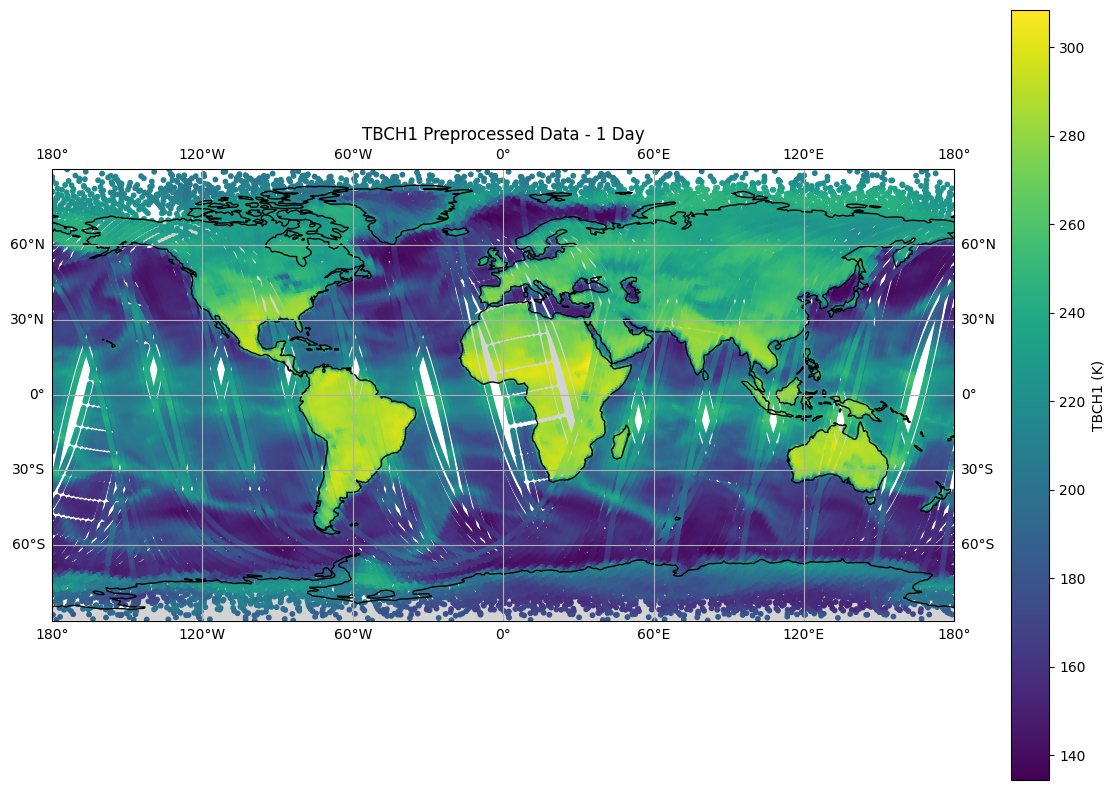

In [3]:
day_ds = xr.open_dataset("../preprocessed-data/march1976_19760302.nc")
plot_geo(day_ds,day_ds.TBCH1,title="TBCH1 Preprocessed Data - 1 Day",cmap_label="TBCH1 (K)")

## 2. Tie Point Calculation

In [4]:
SCAN_POSITIONS = 13
WINDOW = 7   # 15-day smoothing

# Brightness-temperature filtering thresholds (from Table 1)
TB_MIN_ICE  = 100
TB_MAX_ICE  = 274
TB_MIN_WATER =  90
TB_MAX_WATER = 180

# Gradient Ratio ice classification threshold
GR_THRESHOLD = -0.02   # MYI if GR < threshold, FYI otherwise

### Test Masking

In [5]:
def gen_masks(day_ds):
    """ calculate gradient ratio and generate tie point masks for a given day's dataset """
    # -------------------------------------------------------------
    # 1. Gradient ratio (FYI vs MYI discriminator)
    # -------------------------------------------------------------
    GR = (day_ds.TBCH2 - day_ds.TBCH1) / (day_ds.TBCH2 + day_ds.TBCH1)

    # -------------------------------------------------------------
    # 2. Land mask
    # -------------------------------------------------------------
    ocean_mask = (day_ds.lsm == 0) & (day_ds.ELEV<0.05)

    # -------------------------------------------------------------
    # 3. Water tie-point mask (same as paper)
    # -------------------------------------------------------------
    mask_water = (
        (day_ds.siconc == 0) &
        (day_ds.TBCH1 > TB_MIN_WATER) & (day_ds.TBCH1 < TB_MAX_WATER) &
        (day_ds.TBCH2 > TB_MIN_WATER) & (day_ds.TBCH2 < TB_MAX_WATER) &
        ocean_mask
    )

    # -------------------------------------------------------------
    # 4. Ice tie-point mask (one-channel method)
    # -------------------------------------------------------------
    mask_ice = (
        (day_ds.siconc > 0.8) &
        (day_ds.TBCH1 > TB_MIN_ICE) & (day_ds.TBCH1 < TB_MAX_ICE) &
        (day_ds.TBCH2 > TB_MIN_ICE) & (day_ds.TBCH2 < TB_MAX_ICE) &
        ocean_mask
    )

    # -------------------------------------------------------------
    # 5. outer-swath exclusion for FYI/MYI tie-points
    #    outermost beams: scan positions 0 and 12
    #    exclude where |lat| < 80°
    # -------------------------------------------------------------
    outer = day_ds.n13_obs.isin([0, 12])              # dims: (incidence_angle)
    lowlat = np.abs(day_ds.LAT) < 80                  # dims: (time, incidence_angle)

    # pixels to discard
    outer_lowlat = outer & lowlat                     # auto broadcast

    # final mask (True = keep)
    outer_mask = ~outer_lowlat

    # -------------------------------------------------------------
    # 6. FYI / MYI masks
    # -------------------------------------------------------------
    mask_FYI = mask_ice & (GR >= GR_THRESHOLD) & outer_mask
    mask_MYI = mask_ice & (GR <  GR_THRESHOLD) & outer_mask

    # -------------------------------------------------------------
    # 7. Hemisphere masks (as in Table 1)
    # -------------------------------------------------------------
    north_mask = (day_ds.LAT >=  42) & (day_ds.LAT <= 90)
    south_mask = (day_ds.LAT <= -42) & (day_ds.LAT >= -90)

    return GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask


In [6]:
day_ds = xr.open_dataset(f"../preprocessed-data/march1976_19760320.nc")
day_ds = day_ds.rename({"obs": "n13_obs"})

GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask = gen_masks(day_ds)

ocean_mask = (day_ds.lsm == 0) & (day_ds.ELEV<0.05)
"""
water_ds = day_ds.where(mask_water & north_mask, drop=True)
plot_geo(water_ds,water_ds.TBCH1,cmap_label="TBCH1 (K)",title="Water Masked TBCH1 - March 20, 1976",hemisphere="north")

ice_1ch_ds = day_ds.where(mask_ice & north_mask, drop=True)
plot_geo(ice_1ch_ds,ice_1ch_ds.TBCH1,cmap_label="TBCH1 (K)",title="Ice Masked TBCH1 - March 20, 1976",hemisphere="north")

fy_ds = day_ds.where(mask_FYI & north_mask, drop=True)
plot_geo(fy_ds,fy_ds.TBCH1,cmap_label="TBCH1 (K)",title="FYI Masked TBCH1 - March 20, 1976",hemisphere="north")

my_ds = day_ds.where(mask_MYI & north_mask, drop=True)
plot_geo(my_ds,my_ds.TBCH1,cmap_label="TBCH1 (K)",title="MYI Masked TBCH1 - March 20, 1976",hemisphere="north")

ocean_ds = day_ds.where(ocean_mask & north_mask, drop=True)
plot_geo(ocean_ds,ocean_ds.TBCH1,cmap_label="TBCH1 (K)",title="Ocean Masked TBCH1",hemisphere="north")
"""

'\nwater_ds = day_ds.where(mask_water & north_mask, drop=True)\nplot_geo(water_ds,water_ds.TBCH1,cmap_label="TBCH1 (K)",title="Water Masked TBCH1 - March 20, 1976",hemisphere="north")\n\nice_1ch_ds = day_ds.where(mask_ice & north_mask, drop=True)\nplot_geo(ice_1ch_ds,ice_1ch_ds.TBCH1,cmap_label="TBCH1 (K)",title="Ice Masked TBCH1 - March 20, 1976",hemisphere="north")\n\nfy_ds = day_ds.where(mask_FYI & north_mask, drop=True)\nplot_geo(fy_ds,fy_ds.TBCH1,cmap_label="TBCH1 (K)",title="FYI Masked TBCH1 - March 20, 1976",hemisphere="north")\n\nmy_ds = day_ds.where(mask_MYI & north_mask, drop=True)\nplot_geo(my_ds,my_ds.TBCH1,cmap_label="TBCH1 (K)",title="MYI Masked TBCH1 - March 20, 1976",hemisphere="north")\n\nocean_ds = day_ds.where(ocean_mask & north_mask, drop=True)\nplot_geo(ocean_ds,ocean_ds.TBCH1,cmap_label="TBCH1 (K)",title="Ocean Masked TBCH1",hemisphere="north")\n'

In [7]:
# Preallocate storage
# tie_raw_northern[cat][ch][scan] = list of daily values
categories = ["water", "ice", "FYI", "MYI"]
channels   = ["ch1", "ch2"]

tie_raw_northern = {cat: {ch: [[] for _ in range(SCAN_POSITIONS)] for ch in channels}
                    for cat in categories}
tie_raw_southern = {cat: {ch: [[] for _ in range(SCAN_POSITIONS)] for ch in channels}
                    for cat in categories}

# Loop over all 31 days
for day in range(1, 32):

    fname = f"../preprocessed-data/march1976_197603{day:02d}.nc"
    print("Processing", fname)

    day_ds = xr.open_dataset(fname)
    day_ds = day_ds.rename({"obs": "n13_obs"})
    
    #generate masks using function defined earlier
    GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask = gen_masks(day_ds)

    hemisphere_masks = {
        "north": north_mask,
        "south": south_mask
    }

    raw_storage = {
        "north": tie_raw_northern,
        "south": tie_raw_southern
    }

    # Compute tie-points per scan position
    cat_masks = {
        "water": mask_water,
        "ice":   mask_ice,
        "FYI":   mask_FYI,
        "MYI":   mask_MYI
    }

    for scan in range(SCAN_POSITIONS):

        for hemi in ["north", "south"]:

            hemi_mask = hemisphere_masks[hemi]
            storage   = raw_storage[hemi]

            for cat, mask in cat_masks.items():

                # mask for this category + hemisphere
                m = mask & hemi_mask

                # Extract scan slice
                sub = day_ds.isel(n13_obs=scan).where(m.isel(n13_obs=scan))
                #for s in range(13):
                    #print(s, np.isnan(sub.TBCH1).all().values)
                # Store mean for ch1 and ch2
                for ch_name, da in zip(["ch1","ch2"], [sub.TBCH1, sub.TBCH2]):
                    if da.size == 0:
                        storage[cat][ch_name][scan].append(np.nan)
                    else:
                        storage[cat][ch_name][scan].append(float(da.mean()))


Processing ../preprocessed-data/march1976_19760301.nc
Processing ../preprocessed-data/march1976_19760302.nc
Processing ../preprocessed-data/march1976_19760303.nc
Processing ../preprocessed-data/march1976_19760304.nc
Processing ../preprocessed-data/march1976_19760305.nc
Processing ../preprocessed-data/march1976_19760306.nc
Processing ../preprocessed-data/march1976_19760307.nc
Processing ../preprocessed-data/march1976_19760308.nc
Processing ../preprocessed-data/march1976_19760309.nc
Processing ../preprocessed-data/march1976_19760310.nc
Processing ../preprocessed-data/march1976_19760311.nc
Processing ../preprocessed-data/march1976_19760312.nc
Processing ../preprocessed-data/march1976_19760313.nc
Processing ../preprocessed-data/march1976_19760314.nc
Processing ../preprocessed-data/march1976_19760315.nc
Processing ../preprocessed-data/march1976_19760316.nc
Processing ../preprocessed-data/march1976_19760317.nc
Processing ../preprocessed-data/march1976_19760318.nc
Processing ../preprocessed-d

## 3. Perform + Verify Smoothing

In [8]:
def smooth_15day_centered(ts):
    ts = np.array(ts, dtype=float)
    n = len(ts)
    out = np.zeros(n)
    for i in range(n):
        lo = max(0, i-7)
        hi = min(n, i+7+1)
        out[i] = np.nanmean(ts[lo:hi])
    return out

tie_smoothed_north = {
    cat: {
        ch: [smooth_15day_centered(ts) for ts in tie_raw_northern[cat][ch]]
        for ch in ["ch1", "ch2"]
    }
    for cat in ["water", "ice", "FYI", "MYI"]
}

tie_smoothed_south = {
    cat: {
        ch: [smooth_15day_centered(ts) for ts in tie_raw_southern[cat][ch]]
        for ch in ["ch1", "ch2"]
    }
    for cat in ["water", "ice", "FYI", "MYI"]
}



/var/folders/_n/j6tbgncd4nl_y_25l1f3fqvw0000gn/T/ipykernel_5890/3804141126.py:8: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(ts[lo:hi])


In [9]:
#plot_raw_vs_smoothed(tie_raw_northern,tie_smoothed_north, category="ice",channel="ch1", hemisphere="Northern")

In [10]:
day_ds = xr.open_dataset(f"../preprocessed-data/march1976_19760301.nc")
#print(day_ds.TBCH1.shape)

GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask = gen_masks(day_ds)

ocean_mask = (day_ds.lsm == 0) & (day_ds.ELEV<0.05)

day_ds_north = day_ds.where(north_mask & ocean_mask, drop=True)
plot_tiepoints(1,day_ds_north, tie_smoothed_north)

## 4. Apply Sea Ice Concentration Algorithms

### One Channel

In [11]:
def sic_onechannel(day_ds, tie_smoothed, day, use_corrected=False):
    """
    Compute one-channel SIC (22 GHz – CH1)
    Returns a DataArray with dims (time, n13_obs)
    """

    if use_corrected:
        TB22 = day_ds.TBCH1_corr  # (time, n13_obs)
    else:
        TB22 = day_ds.TBCH1  # (time, n13_obs)
    #print("TB22 shape:", TB22.shape)
    scans = day_ds.sizes["n13_obs"]

    # tie points for CH1
    TBw = [tie_smoothed["water"]["ch1"][s][day-1] for s in range(scans)]
    TBi = [tie_smoothed["ice"]["ch1"][s][day-1]   for s in range(scans)]

    TBw_da = xr.DataArray(TBw, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})
    TBi_da = xr.DataArray(TBi, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})

    SIC_raw = (TB22 - TBw_da) / (TBi_da - TBw_da)

    #print("SIC_raw shape:", SIC_raw.shape)
    return SIC_raw.clip(0, 1)

### Two Channel

In [12]:
def sic_twochannel(day_ds, tie_smoothed, day, use_corrected=False):
    """
    Two-channel Comiso SIC using TBCH1 (22 GHz) and TBCH2 (31 GHz)
    Returns a DataArray with dims (time, n13_obs)
    """
    if use_corrected:
        TB22 = day_ds.TBCH1_corr
        TB31 = day_ds.TBCH2_corr
    else:
        TB22 = day_ds.TBCH1
        TB31 = day_ds.TBCH2
    scans = day_ds.sizes["n13_obs"]

    # extract tie points in the Comiso order
    tw22 = [tie_smoothed["water"]["ch1"][s][day-1] for s in range(scans)]
    tw31 = [tie_smoothed["water"]["ch2"][s][day-1] for s in range(scans)]
    tfy22 = [tie_smoothed["FYI"]["ch1"][s][day-1]  for s in range(scans)]
    tfy31 = [tie_smoothed["FYI"]["ch2"][s][day-1]  for s in range(scans)]
    tmy22 = [tie_smoothed["MYI"]["ch1"][s][day-1]  for s in range(scans)]
    tmy31 = [tie_smoothed["MYI"]["ch2"][s][day-1]  for s in range(scans)]

    tw22_da = xr.DataArray(tw22, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})
    tw31_da = xr.DataArray(tw31, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})
    tfy22_da = xr.DataArray(tfy22, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})
    tfy31_da = xr.DataArray(tfy31, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})
    tmy22_da = xr.DataArray(tmy22, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})
    tmy31_da = xr.DataArray(tmy31, dims=["n13_obs"], coords={"n13_obs": day_ds.n13_obs})

    # Calculate coefficients
    af = (tfy31_da - tmy31_da) / (tfy22_da - tmy22_da)
    bf = tmy31_da - af * tmy22_da

    qf = (TB31 - tw31_da) / (TB22 - tw22_da)
    wf = tw31_da - qf * tw22_da

    ti22 = (bf - wf) / (qf - af)
    SIC = (TB22 - tw22_da) / (ti22 - tw22_da)

    return SIC.clip(0, 1)


### Plot Results

In [13]:
def compute_daily_sic(day_ds, tie_smoothed, day, output_dir=None, hemisphere="north",use_corrected=False):
    """
    Adds SIC_1ch and SIC_2ch to the dataset (dims: time, n13_obs)
    """

    ds = day_ds.copy()

    # 1-channel
    SIC1 = sic_onechannel(ds, tie_smoothed, day, use_corrected=use_corrected)
    SIC2 = sic_twochannel(ds, tie_smoothed, day,use_corrected = use_corrected)
    if use_corrected:
        ds["SIC_1ch_corr"] = SIC1
        ds["SIC_1ch_corr"].attrs["long_name"] = "Corrected sea ice concentration (1-channel)"

        # 2-channel
        ds["SIC_2ch_corr"] = SIC2
        ds["SIC_2ch_corr"].attrs["long_name"] = "Corrected sea ice concentration (2-channel)"
    else:
        ds["SIC_1ch"] = SIC1
        ds["SIC_1ch"].attrs["long_name"] = "Sea ice concentration (1-channel)"

        # 2-channel
        ds["SIC_2ch"] = SIC2
        ds["SIC_2ch"].attrs["long_name"] = "Sea ice concentration (2-channel)"

    # Optional: write to file
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        output_name = f"SIC_{hemisphere}_day{day:02d}.nc"
        ds.to_netcdf(os.path.join(output_dir, output_name))
        print("Wrote:", os.path.join(output_dir, output_name))

    return ds


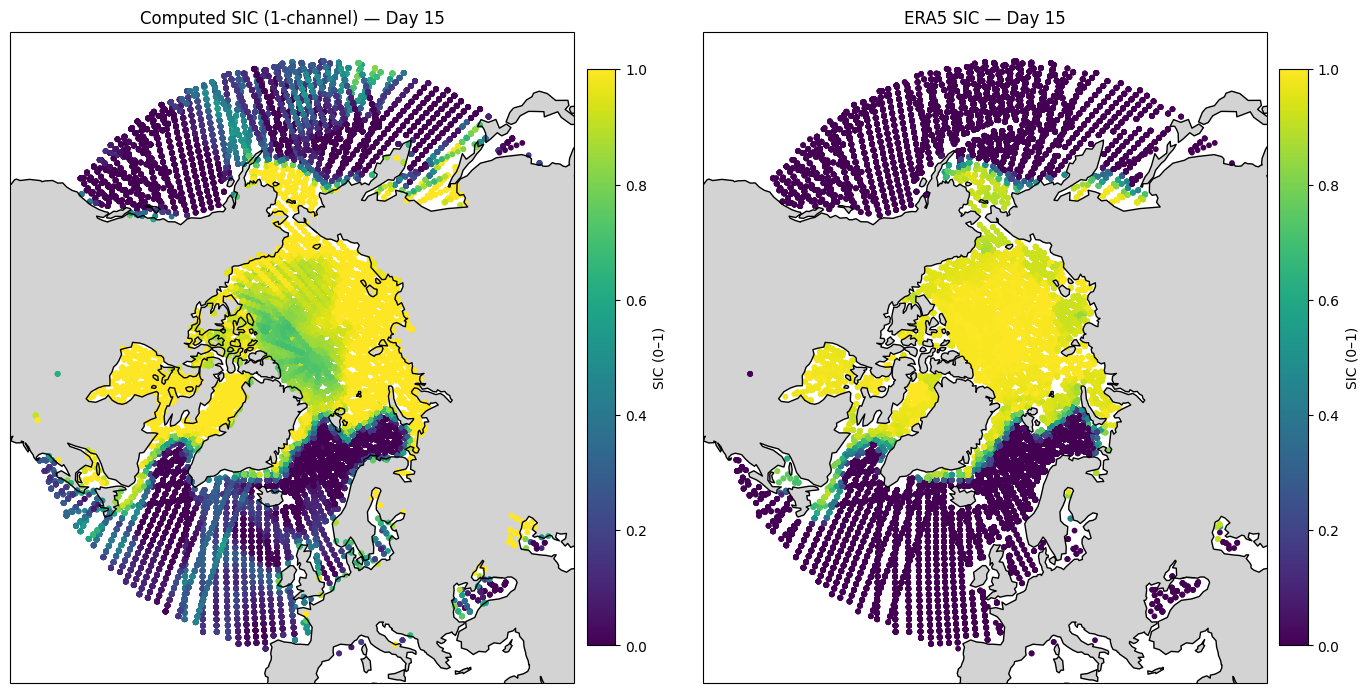

In [14]:
sic = compute_daily_sic(day_ds_north,tie_smoothed_north,15,hemisphere="north")
plot_sic_side_by_side(sic,15)

why is there still stuff on land??

In [15]:
#plot_geo(sic,sic.SIC_1ch-sic.siconc,cmap_label="SIC 1ch - SIC 2ch",title="Difference between 1-channel and 2-channel SIC",hemisphere="north")


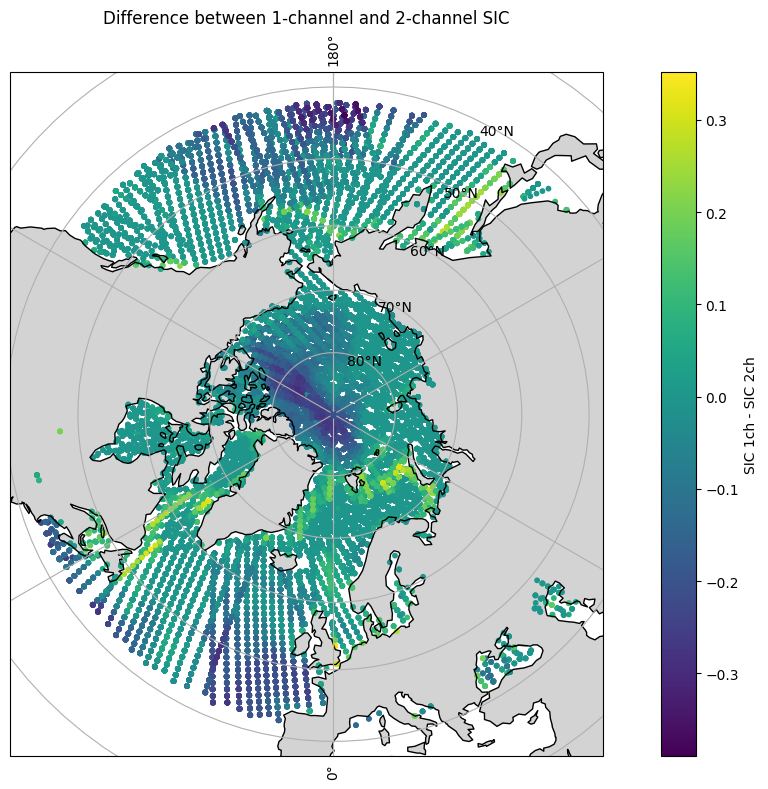

In [16]:
plot_geo(sic,sic.SIC_1ch-sic.SIC_2ch,cmap_label="SIC 1ch - SIC 2ch",title="Difference between 1-channel and 2-channel SIC",hemisphere="north")


## 5. Apply Atmospheric Correction

In [147]:
from scipy.ndimage import uniform_filter
def nan_box_smooth(arr, size=(100,1)):
    arr = np.asarray(arr)
    mask = np.isnan(arr)

    arr_filled = np.where(mask, 0, arr)
    weights = (~mask).astype(float)

    smooth_vals = uniform_filter(arr_filled, size=size)
    smooth_weights = uniform_filter(weights, size=size)

    smooth_weights = np.where(smooth_weights == 0, np.nan, smooth_weights)

    return smooth_vals / smooth_weights

def apply_rtm(ds, verbose=False, smooth=False, alpha1=1,alpha2=1):
    """
    Apply the SCAMS radiative transfer model to each (time, n13_obs) pixel
    and create TBCH1_corr and TBCH2_corr inside the dataset.
    """

    time_len = ds.sizes["time"]
    scan_len = ds.sizes["n13_obs"]

    # Output arrays
    TB1_corr = np.full((time_len, scan_len), np.nan)
    TB2_corr = np.full((time_len, scan_len), np.nan)

    # Atmospheric and surface input fields
                       # (n13_obs)

    vref = np.nanmean(ds.H2OVAP.values)
    lref = np.nanmean(ds.H2OLIQ.values)
    wref = np.nanmean(np.sqrt(ds.u10.values**2 + ds.v10.values**2))
    taref = np.nanmean(ds.t2m.values)
    tsref = np.nanmean(ds.sst.values)

    print('REFS',vref,lref,wref,taref,tsref)

    if smooth:
        V = nan_box_smooth(ds.H2OVAP.values)
        L = nan_box_smooth(ds.H2OLIQ.values)
        W = nan_box_smooth(np.sqrt(ds.u10.values**2 + ds.v10.values**2))
    else:
        V = ds.H2OVAP.values                        # (time, n13_obs)
        L = ds.H2OLIQ.values                        # (time, n13_obs)
        W = np.sqrt(ds.u10.values**2 + ds.v10.values**2)  # (time, n13_obs)
        
    Ta = ds.t2m.values
    Tice = ds.istl1.values                      # (time, n13_obs)
    Ts = ds.sst.values                          # (time, n13_obs)
    c_ice = ds.SIC_1ch.values                   # (time, n13_obs)

    # Fixed arrays required by scams()
    blackbody = np.array([0.9 for _ in range(8)])                      # emissivity arrays for corrected call

    # Loop through pixels
    for t in range(time_len):
        theta = ds.INANG.values[t]
        #print("THEAT",theta)
        for s in range(scan_len):
            # --- Reference calculation ---
            Tb_ref = scams(
                vref,                   # V
                wref,                   # W
                lref,                   # L
                taref ,             # Ta
                tsref,             # Ts
                55,     # incidence angle
                np.full(8, Tice[t,s]),           # Ti_amsrv (len=8) #260
                np.full(8, Tice[t,s]),           # Ti_amsrh (len=8)
                c_ice[t, s],         # ice concentration
                blackbody,           # e_icev (len=8)
                blackbody            # e_iceh (len=8) #0.9
            )

            # --- Full RTM calculation with real inputs ---
            Tb = scams(
                V[t, s],                # water vapor H2OVAP
                W[t, s],                # wind speed sqrt(u10^2+v10^2)
                L[t, s],                # cloud liquid water H2OLIQ
                Ta[t, s],               # Ta → 2m air temperature
                Ts[t, s],               # Ts → sea surface temperature sst
                float(theta[s]),        # incidence angle
                np.full(8, Tice[t,s]),  # Ti_amsrv (all chans get same value) = istl1
                np.full(8, Tice[t,s]),  # Ti_amsrh (all chans get same value) = istl1
                c_ice[t, s],            # 1st pass calculated ice concentration SIC_1ch
                blackbody,              # e_icev = 1 (perfect blackbody)
                blackbody               # e_iceh = 1 (perfect blackbody) #0.9
            )

            if s== 6 and verbose==True:
                # Tb = [T22, T31, T52]
                print("v",V[t,s])
                print("w",W[t,s])
                print("l",L[t,s])
                print("ta", Ta[t,s])
                print("istl1",Tice[t,s])
                print("sst",Ts[t,s])
                print("theta",float(theta[s]))
                print('output tb',Tb)
                print("input tb",ds.TBCH1.values[t, s])
                print("output tbref",Tb_ref)

            if np.any(np.isnan(Tb[:2])) or np.any(np.isnan(Tb_ref[:2])):
                TB1_corr[t, s] = ds.TBCH1.values[t, s]
                TB2_corr[t, s] = ds.TBCH2.values[t, s]
            else:
                TB1_corr[t, s] = ds.TBCH1.values[t, s] + alpha1*(Tb_ref[0] - Tb[0])
                TB2_corr[t, s] = ds.TBCH2.values[t, s] + alpha2*(Tb_ref[1] - Tb[1])

    # Insert into dataset
    ds["TBCH1_corr"] = xr.DataArray(
        TB1_corr, dims=("time", "n13_obs"),
        coords={"time": ds.time, "n13_obs": ds.n13_obs}
    )
    ds["TBCH2_corr"] = xr.DataArray(
        TB2_corr, dims=("time", "n13_obs"),
        coords={"time": ds.time, "n13_obs": ds.n13_obs}
    )

    ds["TBCH1_corr"].attrs["long_name"] = "Corrected TB at 22 GHz"
    ds["TBCH2_corr"].attrs["long_name"] = "Corrected TB at 31 GHz"

    return ds


REFS 6.374838280241068 0.12278034868704261 8.352562562439346 262.0833341522151 274.54099371224913


/Users/dahlia/Projects/DTU/Semester 2/30350 remote sensing/seaicemapping/scripts/rtm.py:144: RuntimeWarning:

invalid value encountered in scalar divide



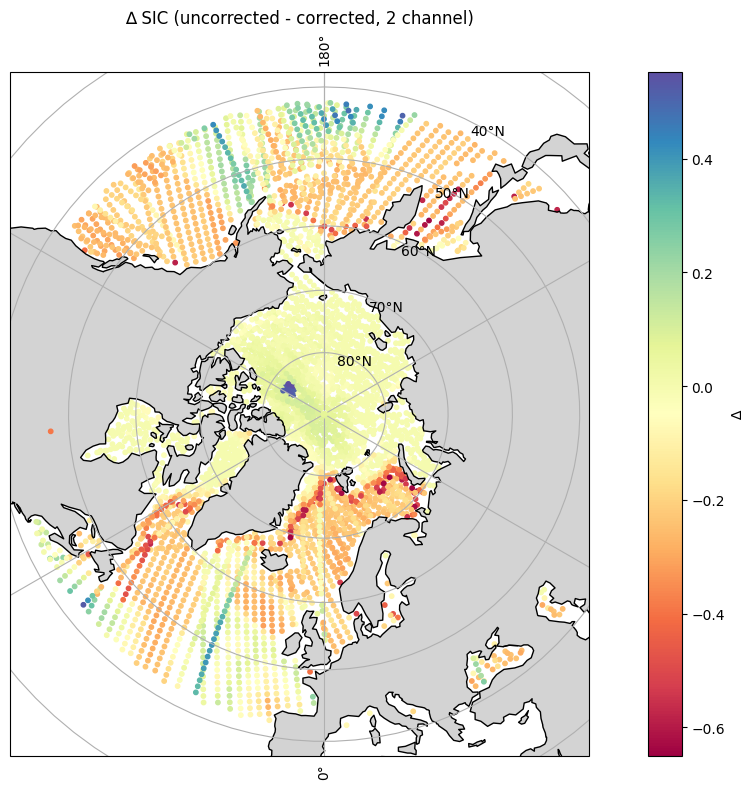

(720, 13)


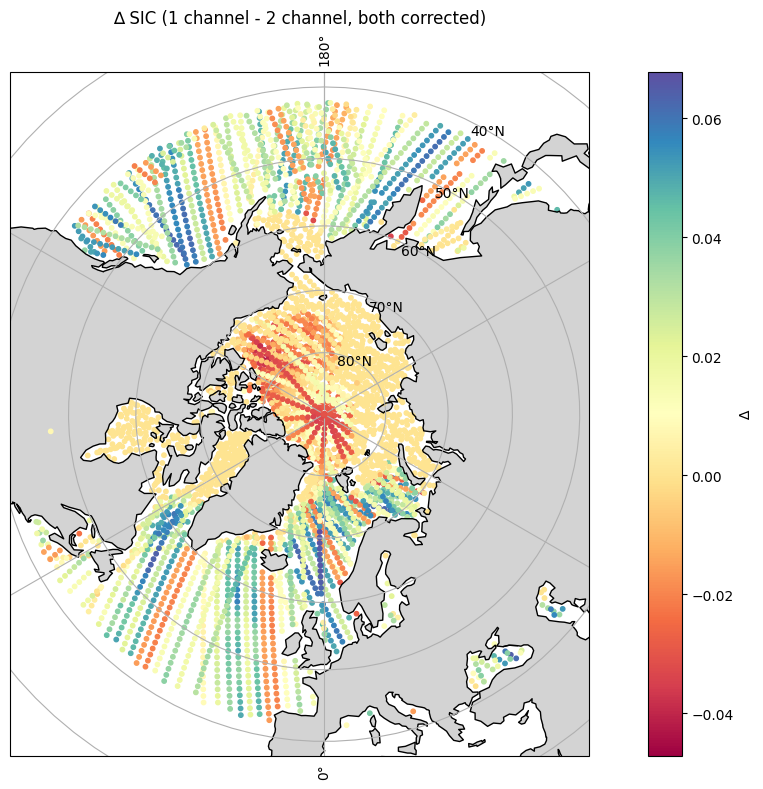

In [186]:
day_ds = xr.open_dataset(f"../preprocessed-data/march1976_19760301.nc")
day_ds = day_ds.rename({"obs": "n13_obs"})
GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask = gen_masks(day_ds)
ocean_mask = (day_ds.lsm == 0) & (day_ds.ELEV<0.05)
day_ds_north = day_ds.where(north_mask & ocean_mask, drop=True)

sic = compute_daily_sic(day_ds_north,tie_smoothed_north,1)
corr=apply_rtm(sic)
sic_corrected = compute_daily_sic(corr, tie_smoothed_north, day, use_corrected=True,hemisphere="north")
#plot_geo(corr,corr.TBCH1_corr,hemisphere="north")
#sic = xr.open_dataset("../outputs/north_sic_rtm_corrected/SIC_north_day02.nc")
plot_geo(sic_corrected,sic_corrected.SIC_2ch-sic_corrected.SIC_2ch_corr,cmap_label="∆",title="∆ SIC (uncorrected - corrected, 2 channel)",hemisphere="north", color="Spectral")
print(sic_corrected.SIC_2ch.values.shape)
plot_geo(sic_corrected,sic_corrected.SIC_1ch_corr-sic_corrected.SIC_2ch_corr,cmap_label="∆",title="∆ SIC (1 channel - 2 channel, both corrected)",hemisphere="north", color="Spectral")

In [204]:
def make_output_data(hemisphere):
    for day in range(1,32):
        day_ds = xr.open_dataset(f"../preprocessed-data/march1976_197603{day:02d}.nc")
        day_ds = day_ds.rename({"obs": "n13_obs"})
        GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask = gen_masks(day_ds)
        ocean_mask = (day_ds.lsm == 0) & (day_ds.ELEV<0.05)
        #print("lsm shape",day_ds.lsm.shape)
        #print("elev shape",day_ds.ELEV.shape)
        #print("ocean mask shape",ocean_mask.shape)
        #print("hemi mask shape", north_mask.shape)
        #compute sic + corrected tb +  for north
        if hemisphere == "north":
            hemisphere_mask = north_mask
            tie_smoothed = tie_smoothed_north
        else:
            hemisphere_mask = south_mask
            tie_smoothed = tie_smoothed_south
        #print("before-shaep",day_ds.TBCH1.shape)
        day_ds_hemisphere = day_ds.where(hemisphere_mask & ocean_mask, drop=True)
        #print('day-ds-shape',day_ds_hemisphere.TBCH1.shape)
        sic_uncorrected = compute_daily_sic(day_ds_hemisphere, tie_smoothed, day, hemisphere=hemisphere)
        rtm_corrected = apply_rtm(sic_uncorrected)
        sic_corrected = compute_daily_sic(rtm_corrected, tie_smoothed, day, use_corrected=True,hemisphere=hemisphere)

        GR, mask_water, mask_ice, mask_FYI, mask_MYI, north_mask, south_mask = gen_masks(sic_corrected)
        time_len = sic_corrected.sizes["time"]
        scan_len = sic_corrected.sizes["n13_obs"]
        # CALC SURFACE TYPE
        surface_type = np.full((time_len, scan_len), np.nan)
        GR_values = GR.values
        print(GR_values.shape)
        sic_values = sic_corrected.SIC_1ch_corr.values
        print(sic_values.shape)
        
        for t in range(time_len):
            for s in range(scan_len):
                #print(sic_values[t,s])
                if np.isnan(sic_values[t,s]):
                    continue
                if sic_values[t,s]>0.3 and GR_values[t,s]<GR_THRESHOLD:
                    surface_type[t,s]=2
                elif sic_values[t,s]>0.3 and GR_values[t,s]>=GR_THRESHOLD:
                    surface_type[t,s]=1
                else:
                    surface_type[t,s]=0
        # Insert into dataset
        sic_corrected["surface_type"] = xr.DataArray(
            surface_type, dims=("time", "n13_obs"),
            coords={"time": sic_corrected.time, "n13_obs": sic_corrected.n13_obs}
        )
        sic_corrected["surface_type"].attrs["long_name"] = "Surface Type: 0=water, 1=FYI, 2 = MYI"
        sic_corrected["GR"] = xr.DataArray(
            GR_values, dims=("time", "n13_obs"),
            coords={"time": sic_corrected.time, "n13_obs": sic_corrected.n13_obs}
        )
        sic_corrected["GR"].attrs["long_name"] = "gradient"
        output_dir = f"../outputs/{hemisphere}_sic_rtm_corrected"
        os.makedirs(output_dir, exist_ok=True)
        output_name = f"SIC_{hemisphere}_day{day:02d}.nc"
        sic_corrected.to_netcdf(os.path.join(output_dir, output_name))
        print("Wrote:", os.path.join(output_dir, output_name))
    

In [206]:
make_output_data("south")

REFS 14.746147294456124 0.20406384862233043 9.134184049336426 276.6154786101799 277.5550226260303


/Users/dahlia/Projects/DTU/Semester 2/30350 remote sensing/seaicemapping/scripts/rtm.py:144: RuntimeWarning:

invalid value encountered in scalar divide

/Users/dahlia/Projects/DTU/Semester 2/30350 remote sensing/seaicemapping/scripts/rtm.py:98: RuntimeWarning:

invalid value encountered in scalar power



(960, 13)
(960, 13)
Wrote: ../outputs/south_sic_rtm_corrected/SIC_south_day01.nc
REFS 14.462959968847352 0.21355140186915889 9.661233545856437 276.6128212490062 277.5980458292263


/Users/dahlia/Projects/DTU/Semester 2/30350 remote sensing/seaicemapping/scripts/rtm.py:144: RuntimeWarning:

invalid value encountered in scalar divide



(1041, 13)
(1041, 13)
Wrote: ../outputs/south_sic_rtm_corrected/SIC_south_day02.nc
REFS 13.976372942269958 0.22194825983682742 10.059479286454613 276.4283792262701 277.5279265969767


...

(761, 13)
(761, 13)
Wrote: ../outputs/south_sic_rtm_corrected/SIC_south_day29.nc
REFS 0.0 0.0 9.096420429201796 274.8841712807394 277.18075874309795


/Users/dahlia/Projects/DTU/Semester 2/30350 remote sensing/seaicemapping/scripts/rtm.py:144: RuntimeWarning:

invalid value encountered in scalar divide



(786, 13)
(786, 13)
Wrote: ../outputs/south_sic_rtm_corrected/SIC_south_day30.nc
REFS 0.0 0.0 9.815522220301894 274.6972246706566 277.2574831648117


/Users/dahlia/Projects/DTU/Semester 2/30350 remote sensing/seaicemapping/scripts/rtm.py:144: RuntimeWarning:

invalid value encountered in scalar divide



(378, 13)
(378, 13)
Wrote: ../outputs/south_sic_rtm_corrected/SIC_south_day31.nc


47.914 353.726
<xarray.DataArray 'TBCH1' ()> Size: 8B
array(252.312)
Attributes:
    long_name:  Brightness Temperature of channel 1 (22.235 GHz) at 13 scan p...
    units:      Kelvin [K]


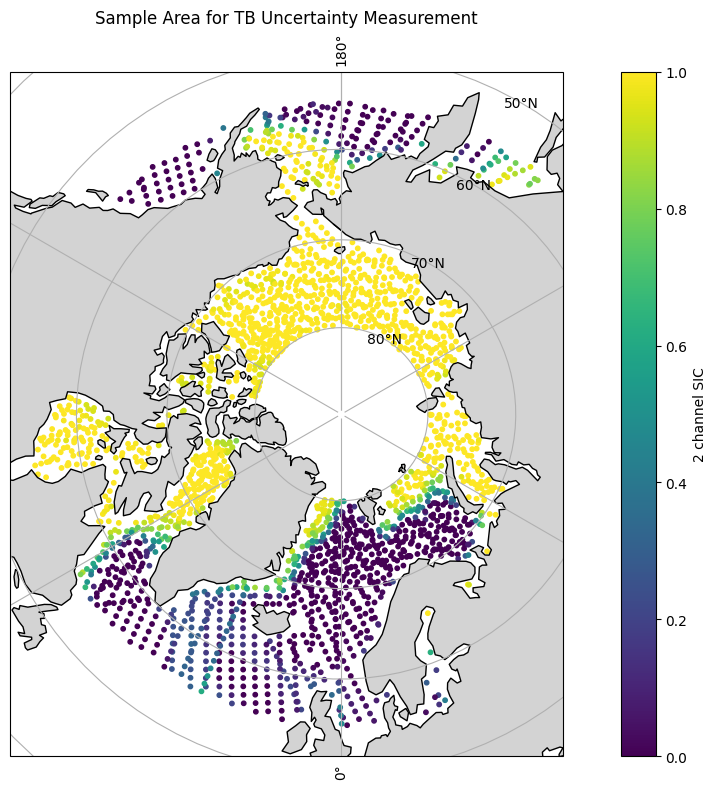

In [165]:
from plotly.subplots import make_subplots
incidence_angles = [-43.2,-36,-28.8,-21.6,-14.4,-7.2,0,7.2,14.4,21.6,28.8,36,43.2]


box = (sic_corrected.LAT < 80) & (sic_corrected.LAT > 55) #& (((sic.LON >0) & (sic.LON < 60)) | (sic.LON>300))
sic_box = sic_corrected.where(box)

Q1 = sic_box.TBCH1.quantile(0.25)
Q3 = sic_box.TBCH1.quantile(0.75)
IQR = Q3 - Q1
# Define the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound.values,upper_bound.values)

print(np.max(sic_box.TBCH1))
iqr= (sic_box.TBCH1 > lower_bound.values) & (sic_box.TBCH1 < upper_bound.values)

inang = (sic_box.n13_obs == 4)
#sic_box_filtered = sic_box.where(iqr)
#sic_box_filtered=sic_box.where(inang)
sic_box_filtered = sic_box
plot_geo(sic_box_filtered,sic_box_filtered.SIC_2ch,hemisphere="north",cmap_label="2 channel SIC", title="Sample Area for TB Uncertainty Measurement")
#sic_box = sic
fig = make_subplots(rows=1, cols=2, subplot_titles=("TBCH1 (22.235 GHz)", "TBCH2 (31.65 GHz)"))
fig.add_trace(go.Scatter(x=incidence_angles,y=[np.nanstd(sic_box_filtered.TBCH1_corr.values[:,s]) for s in range(13)],
                         mode='lines+markers',name="corrected",marker=dict(color='blue')),row=1,col=1)
fig.add_trace(go.Scatter(x=incidence_angles,y=[np.nanstd(sic_box_filtered.TBCH1.values[:,s]) for s in range(13)],
                         mode='lines+markers',name="uncorrected",marker=dict(color='red')),row=1,col=1)
fig.update_xaxes(title_text = "Incidence Angle",row=1,col=1)
fig.update_xaxes(title_text = "Incidence Angle",row=1,col=2)
fig.update_yaxes(title_text = "Standard Deviation",row=1,col=1)
fig.update_yaxes(title_text = "Standard Deviation",row=1,col=2)

fig.add_trace(go.Scatter(x=incidence_angles,y=[np.nanstd(sic_box_filtered.TBCH2_corr.values[:,s]) for s in range(13)],
                         mode='lines+markers',name="corrected",marker=dict(color='blue'),showlegend=False),row=1,col=2)
fig.add_trace(go.Scatter(x=incidence_angles,y=[np.nanstd(sic_box_filtered.TBCH2.values[:,s]) for s in range(13)],
                         mode='lines+markers',name="uncorrected",marker=dict(color='red'),showlegend=False),row=1,col=2)

fig.show()


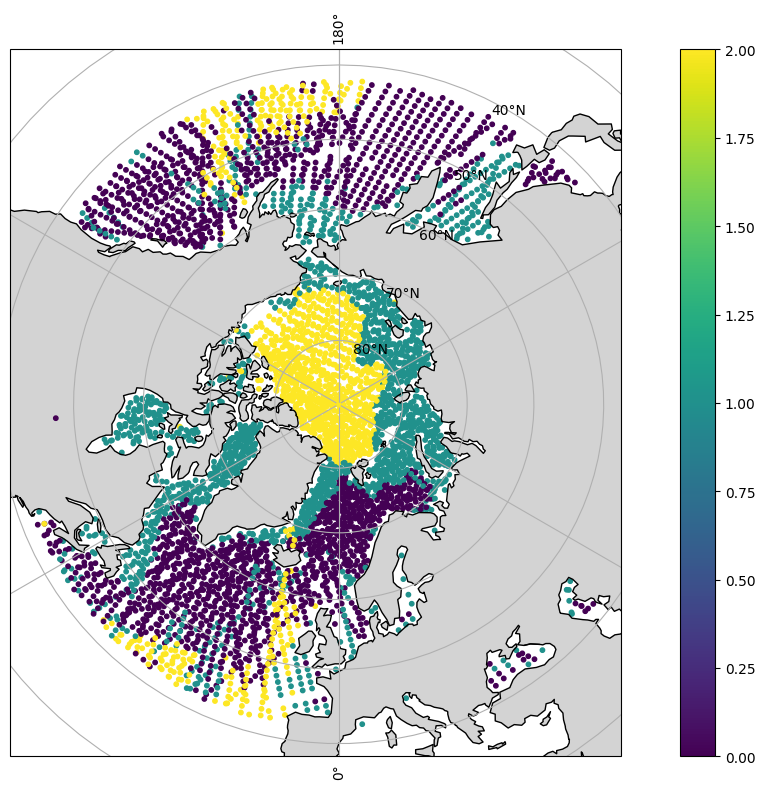

In [201]:
sic = xr.open_dataset("../outputs/north_sic_rtm_corrected/SIC_north_day02.nc")
plot_geo(sic,sic.surface_type,hemisphere="north")